In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

pd.set_option('display.max_columns', None)
print("import successful")

import successful


In [3]:
ticker = "AAPL"

df = yf.download(
    ticker,
    start="2020-02-02",
    end="2025-01-01"
)

df.head()

[*********************100%***********************]  1 of 1 completed


<bound method NDFrame.head of Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2020-02-03   74.335167   75.498382   72.784209   73.285136  173788400
2020-02-04   76.789253   76.979512   75.532110   75.936706  136616400
2020-02-05   77.415413   78.212566   76.813333   77.913929  118826800
2020-02-06   78.320946   78.323356   77.128832   77.685153  105425600
2020-02-07   77.256363   78.069892   76.766314   77.821246  117684000
...                ...         ...         ...         ...        ...
2024-12-24  256.560791  256.570707  253.669247  253.867989   23234700
2024-12-26  257.375580  258.448740  255.994420  256.550862   27237100
2024-12-27  253.967392  257.057664  251.453455  256.193162   42355300
2024-12-30  250.598923  251.890673  249.158131  250.628731   35557500
2024-12-31  248.830200  251.672044  247.846480  250.837380  

In [4]:
df.to_csv("../data/raw/aapl_raw.csv")

In [5]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1237 entries, 2020-02-03 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1237 non-null   float64
 1   (High, AAPL)    1237 non-null   float64
 2   (Low, AAPL)     1237 non-null   float64
 3   (Open, AAPL)    1237 non-null   float64
 4   (Volume, AAPL)  1237 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.0 KB


In [6]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1237.000000,1237.000000,1237.000000,1237.000000,1.237000e+03
mean,152.672391,154.210153,150.959281,152.518503,8.973645e+07
std,40.997627,41.112923,40.796948,40.938263,5.316230e+07
min,54.163712,55.160709,51.324807,55.059320,2.323470e+07
25%,127.500519,128.869587,125.987127,127.596722,5.494580e+07
50%,150.873260,152.396434,148.774760,150.489192,7.569380e+07
75%,176.487152,177.777697,174.868485,176.131057,1.055686e+08
max,257.375580,258.448740,255.994420,256.550862,4.265100e+08


In [7]:
df.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.reset_index()

df.head()

Price,index,Date,Close,High,Low,Open,Volume
Ticker,,,AAPL,AAPL,AAPL,AAPL,AAPL
0,0,2020-02-03,74.335167,75.498382,72.784209,73.285136,173788400
1,1,2020-02-04,76.789253,76.979512,75.532110,75.936706,136616400
2,2,2020-02-05,77.415413,78.212566,76.813333,77.913929,118826800
3,3,2020-02-06,78.320946,78.323356,77.128832,77.685153,105425600
4,4,2020-02-07,77.256363,78.069892,76.766314,77.821246,117684000


In [12]:
df['Date'] = pd.to_datetime(df['Date'])

df.dtypes

Price   Ticker
index                     int64
Date              datetime64[s]
Close   AAPL            float64
High    AAPL            float64
Low     AAPL            float64
Open    AAPL            float64
Volume  AAPL              int64
dtype: object

In [13]:
df = df.ffill()

In [14]:
df = df.drop_duplicates()

df.duplicated().sum()

np.int64(0)

In [15]:
df.shape

(1237, 7)

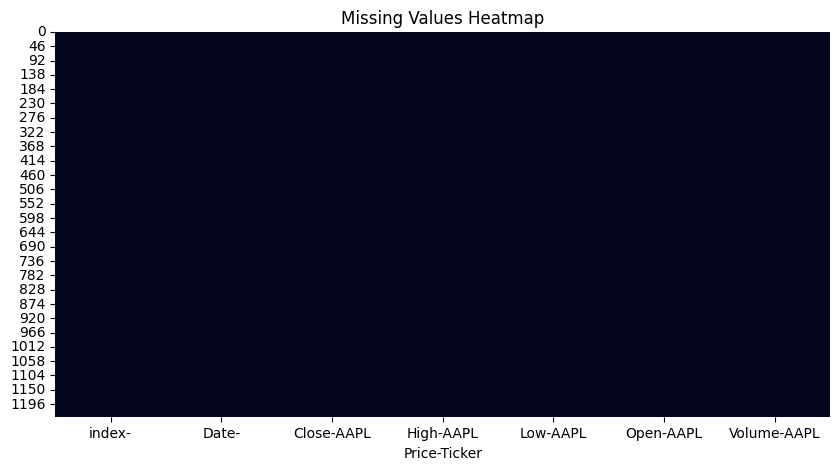

In [16]:
plt.figure(figsize=(10,5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")

plt.show()

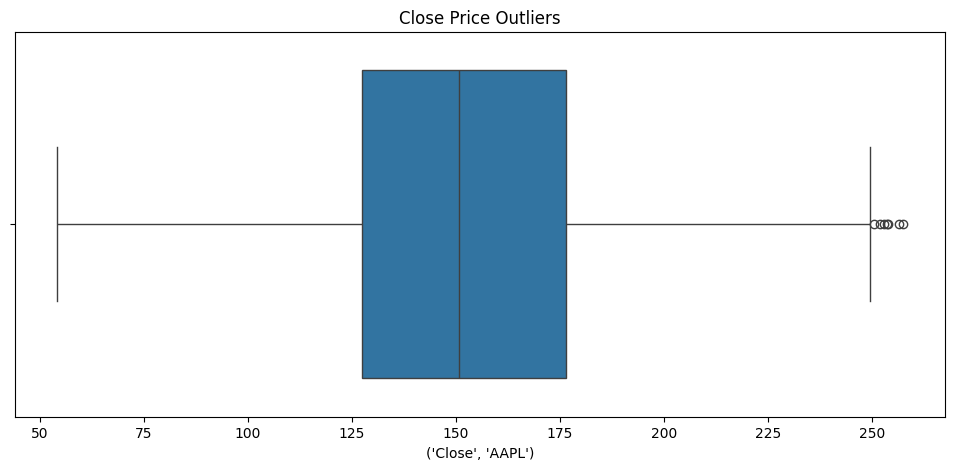

In [18]:
plt.figure(figsize=(12,5))

sns.boxplot(x=df[('Close', 'AAPL')])

plt.title("Close Price Outliers")

plt.show()



In [19]:
Q1 = df['Close'].quantile(0.25)
Q3 = df['Close'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: Ticker
AAPL    54.020569
dtype: float64
Upper Bound: Ticker
AAPL    249.967102
dtype: float64


In [20]:
df = df[
    (df['Close'] >= lower_bound) &
    (df['Close'] <= upper_bound)
]

In [21]:
df.shape

(1237, 7)

In [22]:
df['MA_5'] = df['Close'].rolling(window=5).mean()

In [23]:
df['MA_10'] = df['Close'].rolling(window=10).mean()

In [25]:
df['Daily_Return'] = df['Close'].pct_change()

In [26]:
df['Volatility'] = df['Daily_Return'].rolling(window=10).std()

In [27]:
delta = df['Close'].diff()

gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss

df['RSI'] = 100 - (100 / (1 + rs))

In [28]:
df = df.dropna()

In [29]:
df.head()

Price,index,Date,Close,High,Low,Open,Volume,MA_5,MA_10,Daily_Return,Volatility,RSI
Ticker,,,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,


In [34]:
df.to_csv("aapl.processed.csv", index=False)

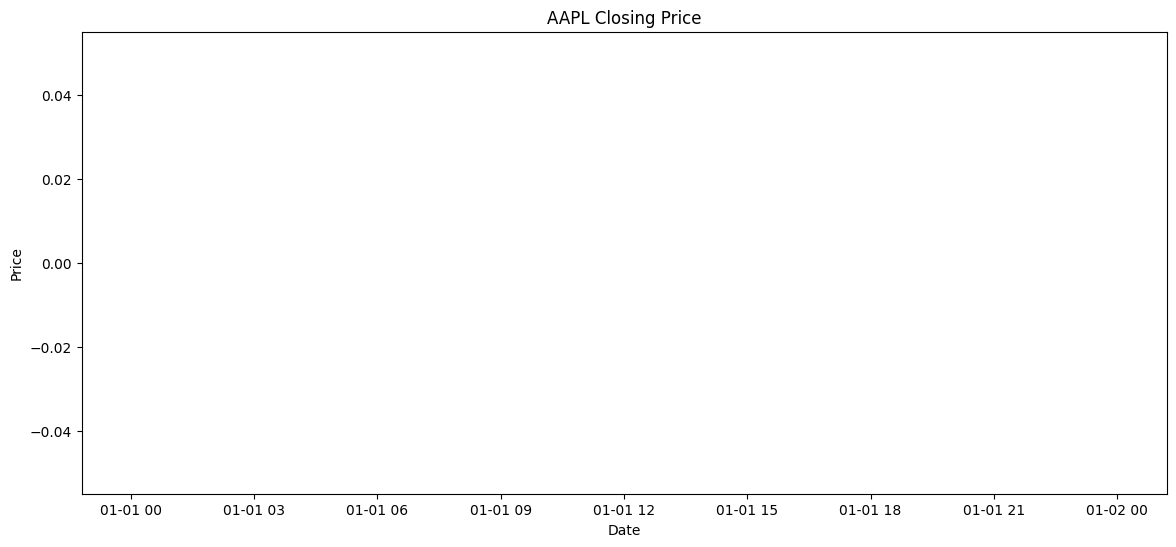

In [35]:
plt.figure(figsize=(14,6))

plt.plot(df['Date'], df['Close'])

plt.title("AAPL Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

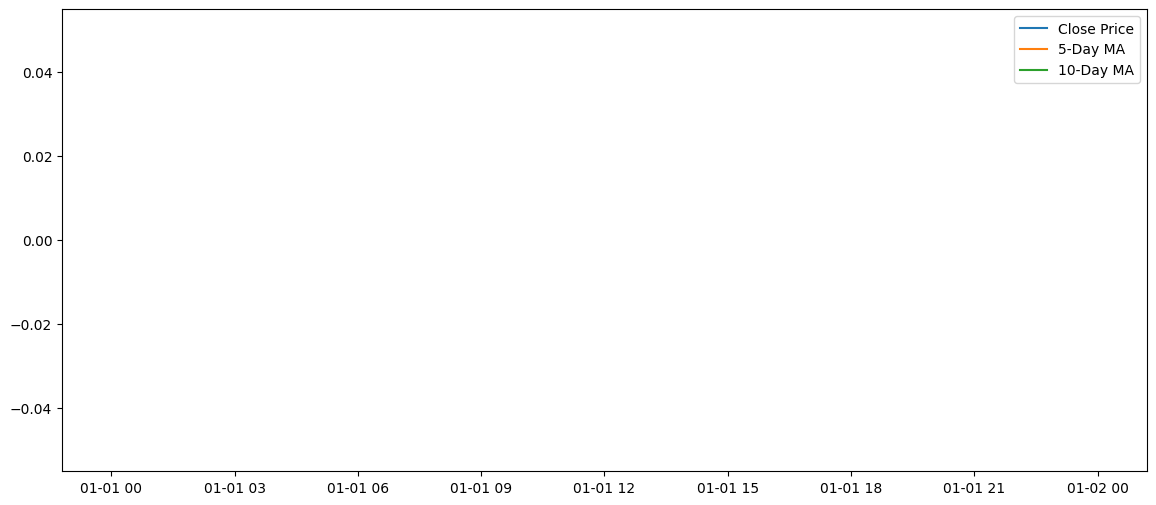

In [36]:
plt.figure(figsize=(14,6))

plt.plot(df['Date'], df['Close'], label='Close Price')
plt.plot(df['Date'], df['MA_5'], label='5-Day MA')
plt.plot(df['Date'], df['MA_10'], label='10-Day MA')

plt.legend()

plt.show()